According to https://liana-py.readthedocs.io/en/latest/notebooks/targeted.html 

In [ ]:
suppressPackageStartupMessages({
  library(Seurat)
  library(liana)
  library(dplyr)
  library(tidyr)
  library(tibble)
  library(stringr)
  library(purrr)
  library(ggplot2)
  library(forcats)
  library(circlize)
  library(DESeq2)
})

set.seed(123)

# "gated_ImmuneAging.rds", "gated_heart_processed.rds", "gated_sepsis_processed.rds", "gated_vaccine_processed.rds", "gated_our_dataset_processed.rds"
#file_name <- "gated_ImmuneAging.rds"
#file_name <- "gated_heart_processed.rds" 
file_name <- "gated_sepsis_processed.rds" 
#file_name <- "gated_vaccine_processed.rds" 
#file_name <- "gated_our_dataset_processed.rds" 

input_file <- "/nfs/home/students/i.kaciran/FoPra_PLAs/data//datasets/gated_sepsis_processed.rds"
out_dir <- "/nfs/home/students/i.kaciran/FoPra_PLAs/results/differential_ccs/v2/liana_plus"
plot_dir <- file.path(out_dir, "plots")

dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)
dir.create(plot_dir, recursive = TRUE, showWarnings = FALSE)

message("Output directory: ", out_dir)

Output directory: /nfs/home/students/i.kaciran/FoPra_PLAs/results/differential_ccs/v2/liana_plus



# 1. Load & Prep Data

In [3]:
seurat_obj <- readRDS(input_file)

DefaultAssay(seurat_obj)
ncol(seurat_obj)
nrow(seurat_obj)
colnames(seurat_obj@meta.data)

[1] "RNA"

[1] 285043

[1] 37487

[1] "orig.ident"                             
 [2] "nCount_RNA"                             
 [3] "nFeature_RNA"                           
 [4] "nCount_ADT"                             
 [5] "nFeature_ADT"                           
 [6] "sample"                                 
 [7] "donor_id"                               
 [8] "cell_barcodes"                          
 [9] "scRNA.seq"                              
[10] "TCR"                                    
[11] "BCR"                                    
[12] "CITE.seq"                               
[13] "Bulk.RNA.seq"                           
[14] "Olink.proteomics"                       
[15] "Gender"                                 
[16] "Age"                                    
[17] "Sample.Collection.Date"                 
[18] "Sample.Collection.Site"                 
[19] "Group"                                  
[20] "Sepsis.Infection.Source"                
[21] "Ethnicity"                              
[22] "Chronic.comorbidity.None"               
[23] "Cardiovascular.compromise"              
[24] "COPD"                                   
[25] "Hypertension"                           
[26] "Diabetes"                               
[27] "Respiratory.insufficiency"              
[28] "Renal.insufficiency"                    
[29] "Tuberculosis"                           
[30] "Length.of.ICU.stay.days"                
[31] "Length.of.hospital.stay.days"           
[32] "X14.day.mortality..Deceased.1.Living.0."
[33] "X28.day.mortality..Deceased.1.Living.0."
[34] "X90.day.mortality..Deceased.1.Living.0."
[35] "Gram.positive.bacteria"                 
[36] "Gram.negative.bacteria"                 
[37] "Virus"                                  
[38] "Fungi"                                  
[39] "Microbiology.laboratory..Unknown"       
[40] "SOFA.score"                             
[41] "Shock"                                  
[42] "Organ.failure"                          
[43] "Mechanical.ventilation"                 
[44] "percent.mt"                             
[45] "percent.ribo"                           
[46] "percent.hb"                             
[47] "mt_outlier_all"                         
[48] "is_outlier_RNA"                         
[49] "is_outlier_protein"                     
[50] "is_outlier"                             
[51] "scDblFinder.class"                      
[52] "scDblFinder.score"                      
[53] "RNA_snn_res.0.8"                        
[54] "seurat_clusters"                        
[55] "RNA_snn_res.0.25"                       
[56] "RNA.weight"                             
[57] "ADT.weight"                             
[58] "leiden_0.8_totalVI"                     
[59] "leiden_0.25_totalVI"                    
[60] "celltype_full"                          
[61] "lineage"                                
[62] "pla_status"                             
[63] "celltype"

In [4]:
sample_col    <- "sample"       # technical / sample-level replicate
donor_col     <- "donor_id"     # biological donor
celltype_col  <- "celltype"     # broad cell type
celltype_full <- "celltype_full" # more detailed cell type
condition_col <- "pla_status"   # PLA vs platelet-free
lineage_col   <- "lineage"

In [6]:
table(seurat_obj$pla_status, useNA = "ifany")
table(seurat_obj$pla_status, seurat_obj$lineage)


          PLA platelet-free 
        39405        245638 

               
                   DCs NK cells Unassigned neutrophils CD8 T cells B cells
  PLA             2298     2443          0           0        7504     488
  platelet-free   3440    31768     117212        4210       19400   20788
               
                CD4 T cells Monocytes
  PLA                  5680     20992
  platelet-free       45049      3479

In [9]:
head(seurat_obj$sample)

GSM8571042_Abd-S111_AAACCTGAGCAGCCTC-1 GSM8571042_Abd-S111_AAACCTGAGCGAAGGG-1 
                 "GSM8571042_Abd-S111"                  "GSM8571042_Abd-S111" 
GSM8571042_Abd-S111_AAACCTGAGCGGCTTC-1 GSM8571042_Abd-S111_AAACCTGAGTGTACTC-1 
                 "GSM8571042_Abd-S111"                  "GSM8571042_Abd-S111" 
GSM8571042_Abd-S111_AAACCTGCAGGGCATA-1 GSM8571042_Abd-S111_AAACCTGGTACGAAAT-1 
                 "GSM8571042_Abd-S111"                  "GSM8571042_Abd-S111"

# 2. Pseudobulking

The tutorial uses decoupler (Python) to pseudobulk. There also exists a decoupleR for R from saezlab but it seems like it has no pseudobulking option. Hence, I will use Seurat's AggregateExpression function, which is "primarily used to generate "pseudobulk" profiles by summing raw feature counts across defined groups of cells (such as cell types, clusters, or conditions)".

We first need to create a column by which Seurat will be grouping (aggregating). 
AggregateExpression changes underscores to dashes, so we need to clean the sample names.


In [11]:
seurat_obj$sample_clean <- gsub("_", "-", seurat_obj$sample)

Now we are creating the column:

In [12]:
# e.g. 
# sample_clean   lineage    pla_status
# S1             Mono       PLA
# S1             Mono       platelet_free
# S2             Tcell      PLA
# -> 
# pb_group
# S1|Mono|PLA
# S1|Mono|platelet_free
# S2|Tcell|PLA


# e.g. GSM8571042-Abd-S111|B cells|PLA


seurat_obj$pb_group <- paste(
  seurat_obj$sample_clean,
  seurat_obj$lineage,
  seurat_obj$pla_status,
  sep = "|"
)

head(seurat_obj@meta.data[, c("sample_clean", "lineage", "pla_status", "pb_group")])
table(seurat_obj$pb_group)

,sample_clean,lineage,pla_status,pb_group
,<chr>,<fct>,<chr>,<chr>
GSM8571042_Abd-S111_AAACCTGAGCAGCCTC-1,GSM8571042-Abd-S111,Unassigned,platelet-free,GSM8571042-Abd-S111|Unassigned|platelet-free
GSM8571042_Abd-S111_AAACCTGAGCGAAGGG-1,GSM8571042-Abd-S111,neutrophils,platelet-free,GSM8571042-Abd-S111|neutrophils|platelet-free
GSM8571042_Abd-S111_AAACCTGAGCGGCTTC-1,GSM8571042-Abd-S111,Unassigned,platelet-free,GSM8571042-Abd-S111|Unassigned|platelet-free
GSM8571042_Abd-S111_AAACCTGAGTGTACTC-1,GSM8571042-Abd-S111,Unassigned,platelet-free,GSM8571042-Abd-S111|Unassigned|platelet-free
GSM8571042_Abd-S111_AAACCTGCAGGGCATA-1,GSM8571042-Abd-S111,B cells,platelet-free,GSM8571042-Abd-S111|B cells|platelet-free
GSM8571042_Abd-S111_AAACCTGGTACGAAAT-1,GSM8571042-Abd-S111,CD4 T cells,platelet-free,GSM8571042-Abd-S111|CD4 T cells|platelet-free



              GSM8571042-Abd-S111|B cells|PLA 
                                           28 
    GSM8571042-Abd-S111|B cells|platelet-free 
                                          751 
          GSM8571042-Abd-S111|CD4 T cells|PLA 
                                          187 
GSM8571042-Abd-S111|CD4 T cells|platelet-free 
                                         1522 
          GSM8571042-Abd-S111|CD8 T cells|PLA 
                                          212 
GSM8571042-Abd-S111|CD8 T cells|platelet-free 
                                          323 
                  GSM8571042-Abd-S111|DCs|PLA 
                                           24 
        GSM8571042-Abd-S111|DCs|platelet-free 
                                           79 
            GSM8571042-Abd-S111|Monocytes|PLA 
                                          364 
  GSM8571042-Abd-S111|Monocytes|platelet-free 
                                           52 
         GSM8571042-Abd-S111|NA|platelet-free 
            

In [ ]:
pseudobulk <- AggregateExpression(
    object = seurat_obj,
    group.by = "pb_group",
    assays = "RNA",
    slot = "counts",
    verbose = TRUE
)


In [21]:
counts <- pseudobulk$RNA

In [ ]:
head(pseudobulk)
head(counts) # actual rna matrix

  [[ suppressing 32 column names ‘GSM8571042-Abd-S111|B cells|PLA’, ‘GSM8571042-Abd-S111|B cells|platelet-free’, ‘GSM8571042-Abd-S111|CD4 T cells|PLA’ ... ]]

  [[ suppressing 32 column names ‘GSM8571042-Abd-S111|B cells|PLA’, ‘GSM8571042-Abd-S111|B cells|platelet-free’, ‘GSM8571042-Abd-S111|CD4 T cells|PLA’ ... ]]

  [[ suppressing 32 column names ‘GSM8571042-Abd-S111|B cells|PLA’, ‘GSM8571042-Abd-S111|B cells|platelet-free’, ‘GSM8571042-Abd-S111|CD4 T cells|PLA’ ... ]]



$RNA
37487 x 598 sparse Matrix of class "dgCMatrix"
                                                                                      
OR4F16             .    .    .    .    .    .    .     .      .     .    .     .     .
TNFRSF4            .    4   44  323    4   18    .     .      .     .    .     1     .
TNFRSF18           .   19   22   81    1    6    .     .      .     .    .     .     2
ATAD3B             5   84    2   63    8   25    3     6     27     3    .    15     5
THAP3              3   85   16  105   13   19    3    10     40     6    .    15     2
ENSG00000260179    .    .    .    1    .    .    1     .      .     .    .     .     .
ENSG00000234396    .    .    .    .    .    .    .     .      .     .    .     .     .
ENSG00000228037    .    1    .    4    .    1    .     .      .     .    .     .     .
PRDM16             .    .    .    .    .    .    .     .      .     .    .     .     .
PRKCZ              1   39   13   65   17   14    1     3      3     .    .    

  [[ suppressing 598 column names ‘GSM8571042-Abd-S111|B cells|PLA’, ‘GSM8571042-Abd-S111|B cells|platelet-free’, ‘GSM8571042-Abd-S111|CD4 T cells|PLA’ ... ]]



6 x 598 sparse Matrix of class "dgCMatrix"
                                                                              
OR4F16          .  .  .   .  .  . .  .  . . .  . .  .   . .  . .  . .  . . . .
TNFRSF4         .  4 44 323  4 18 .  .  . . .  1 .  4  50 .  . 6 61 .  . . . .
TNFRSF18        . 19 22  81  1  6 .  .  . . .  . 2 14  18 .  . 1  8 .  . . . .
ATAD3B          5 84  2  63  8 25 3  6 27 3 . 15 5 44 165 .  8 . 14 1 11 . 1 5
THAP3           3 85 16 105 13 19 3 10 40 6 . 15 2 42 222 . 25 3 29 7 20 1 2 6
ENSG00000260179 .  .  .   1  .  . 1  .  . . .  . .  .   2 .  . .  1 .  . . . 1
                                                                               
OR4F16          . .  . .  .   . .  .  .   .  .  . . .  . . . .  .  .   . .  . .
TNFRSF4         . .  . 1 27  85 .  5 43 160  2  . . .  . . . .  9 26  30 .  6 3
TNFRSF18        . .  . . 32  63 3  5 16  16  3  2 . 1  1 . . . 24 84  10 .  9 .
ATAD3B          1 . 10 1 36 118 4 20  1  37 23 27 5 4 12 . . 6  1 22 102 . 23 2
THAP

Before aggregation: genes × cells<br>
After aggregation: genes × sample-lineage-condition groups<br>

e.g. TNFRSF4    4 in column GSM8571042-Abd-S111|B cells|platelet-free means: <br>
in all B cells from sample GSM8571042-Abd-S111 in the platelet-free condition, the total raw RNA count for TNFRSF4 is 4

# 3. DESeq

We now need to restructure our data so that DESeq will accept it.
<br>
Python:
<br>
pdata.X      = pseudobulk counts<br>
pdata.obs    = pseudobulk sample metadata<br>
<br>
R:
counts       = pseudobulk$RNA<br>
pb_meta      = pseudobulk sample metadata

In [23]:
pb_meta <- data.frame(
  pb_group = colnames(counts),
  stringsAsFactors = FALSE
)

pb_meta <- tidyr::separate(
  data = pb_meta,
  col = "pb_group",
  into = c("sample_clean", "lineage", "pla_status"),
  sep = "\\|",
  remove = FALSE
)

rownames(pb_meta) <- pb_meta$pb_group

In the tutorial they run DESeq for each lineage/cell group.

In [28]:
dea_results <- list()

pb_meta$pla_status <- gsub("-", "_", pb_meta$pla_status)

for (lin in unique(pb_meta[[lineage_col]])) {
    counts_lin <- counts[, pb_meta[[lineage_col]] == lin]
    meta_lin   <- pb_meta[pb_meta[[lineage_col]] == lin, ]

    meta_lin$pla_status <- factor(
        meta_lin$pla_status,
        levels = c("platelet_free", "PLA")
    )

    print(table(meta_lin$pla_status))

    if (length(unique(na.omit(meta_lin$pla_status))) < 2) {
        message("Skipping ", lin, ": only one pla_status present")
        next
    }

    # DESeq2: PLA vs platelet-free inside this lineage
    # creates deseq2 object

    dds <- DESeqDataSetFromMatrix(
    countData = counts_lin,
    colData   = meta_lin, # rows of colData correspond to cols of countData
    design    = ~ pla_status # model gene counts as a function of pla_status
    # for every gene deseq asks: does expression differ between PLA & platelet-free
    )

    # runs deseq
    dds <- DESeq(dds)

    res <- results(
        dds,
        contrast = c("pla_status", "PLA", "platelet_free")

        # log2FoldChange = log2(PLA / platelet-free)
        # positive log2FC = higher in PLA
        # negative log2FC = higher in platelet-free
        )

    res_df <- as.data.frame(res)
    res_df$gene <- rownames(res_df)
    res_df$lineage <- lin

    dea_results[[lin]] <- res_df

}


platelet_free           PLA 
           40            40 


converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 180 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing




platelet_free           PLA 
           40            40 


converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 173 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing




platelet_free           PLA 
           40            40 


...

Skipping neutrophils: only one pla_status present




platelet_free           PLA 
           40            40 


converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 208 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing




platelet_free           PLA 
           40             0 


Skipping Unassigned: only one pla_status present



The reason why we always have 40/40 is (I suppose):
40 sample_clean values, and each sample_clean has both a PLA and platelet-free pseudobulk column for that lineage

S1|B cells|PLA
S1|B cells|platelet_free
S2|B cells|PLA
S2|B cells|platelet_free
...
S40|B cells|PLA
S40|B cells|platelet_free

In [29]:
length(unique(pb_meta$sample_clean))
table(pb_meta$lineage, pb_meta$pla_status)

[1] 40

             
              PLA platelet_free
  B cells      40            40
  CD4 T cells  40            40
  CD8 T cells  40            40
  DCs          40            40
  Monocytes    40            40
  NA            0            38
  neutrophils   0            40
  NK cells     40            40
  Unassigned    0            40

In [37]:
dea_table <- dplyr::bind_rows(dea_results)
head(dea_table)
str(dea_table)
# each row = one gene tested in one lineage

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,lineage
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
OR4F16...1,0.00000000,NA,NA,NA,NA,NA,OR4F16,B cells
TNFRSF4...2,0.51445732,1.9681945,0.5269684,3.7349383,0.0001877612,0.0006231043,TNFRSF4,B cells
TNFRSF18...3,0.77585558,0.4149190,0.4481017,0.9259483,0.3544728660,0.4145808557,TNFRSF18,B cells
ATAD3B...4,3.18605868,0.2590089,0.2503922,1.0344129,0.3009431688,0.3584588056,ATAD3B,B cells
THAP3...5,5.10771304,-0.4154261,0.2372339,-1.7511247,0.0799244346,0.1282116466,THAP3,B cells
ENSG00000260179...6,0.00544752,4.8303051,2.9204220,1.6539750,0.0981325917,0.1370572585,ENSG00000260179,B cells


'data.frame':	224922 obs. of  8 variables:
 $ baseMean      : num  0 0.514 0.776 3.186 5.108 ...
 $ log2FoldChange: num  NA 1.968 0.415 0.259 -0.415 ...
 $ lfcSE         : num  NA 0.527 0.448 0.25 0.237 ...
 $ stat          : num  NA 3.735 0.926 1.034 -1.751 ...
 $ pvalue        : num  NA 0.000188 0.354473 0.300943 0.079924 ...
 $ padj          : num  NA 0.000623 0.414581 0.358459 0.128212 ...
 $ gene          : chr  "OR4F16" "TNFRSF4" "TNFRSF18" "ATAD3B" ...
 $ lineage       : chr  "B cells" "B cells" "B cells" "B cells" ...


TNFRSF4 in B cells has log2FoldChange = 1.968, padj = 0.000623, meaning TNFRSF4 is significantly higher in PLA than platelet_free in B cells. First row means the gene had essentially no counts, so DESeq2 could not test it.

In [38]:
dea_table %>%
  dplyr::filter(padj < 0.05) %>%
  dplyr::arrange(padj) %>%
  head()

str(dea_table)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,lineage
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
FYB1...1,47.45176,4.487839,0.18200609,24.65763,3.047981e-134,6.384605e-130,FYB1,B cells
BRI3...2,88.40433,2.450691,0.10175134,24.08510,3.581221e-128,3.750792e-124,BRI3,B cells
NCF2...3,33.80834,3.463044,0.14617338,23.69135,4.428016e-124,3.091788e-120,NCF2,B cells
MYO1F...4,33.89010,2.898008,0.12648786,22.91135,3.580636e-116,1.875090e-112,MYO1F,B cells
JAML...5,25.37414,5.355026,0.23507355,22.78021,7.203726e-115,3.017929e-111,JAML,B cells
RAC1...6,101.83636,1.582305,0.06968285,22.70724,3.800021e-114,1.326651e-110,RAC1,B cells


'data.frame':	224922 obs. of  8 variables:
 $ baseMean      : num  0 0.514 0.776 3.186 5.108 ...
 $ log2FoldChange: num  NA 1.968 0.415 0.259 -0.415 ...
 $ lfcSE         : num  NA 0.527 0.448 0.25 0.237 ...
 $ stat          : num  NA 3.735 0.926 1.034 -1.751 ...
 $ pvalue        : num  NA 0.000188 0.354473 0.300943 0.079924 ...
 $ padj          : num  NA 0.000623 0.414581 0.358459 0.128212 ...
 $ gene          : chr  "OR4F16" "TNFRSF4" "TNFRSF18" "ATAD3B" ...
 $ lineage       : chr  "B cells" "B cells" "B cells" "B cells" ...


# 4. DEA to Ligand-Receptor Interactions

We now have DEA results per gene. Now we can combine them into statistics of potentially deregulated ligand-receptor interactions. Issue: Liana+ (Python) provides a function multi.df_to_lr that calculates average expression as well as proportions based on passed adata object, combines those with DEA results and a ligand-receptor resource. -> We do not have that in R.

Method on GitHub: https://github.com/saezlab/liana-py/blob/main/src/liana/multi/df_to_lr.py#L19

Function basically does this: 
DE genes per cell type  +  known ligand-receptor pairs = DE-informed ligand-receptor interactions between cell types

We can try to recreate this method. Goal:<br>
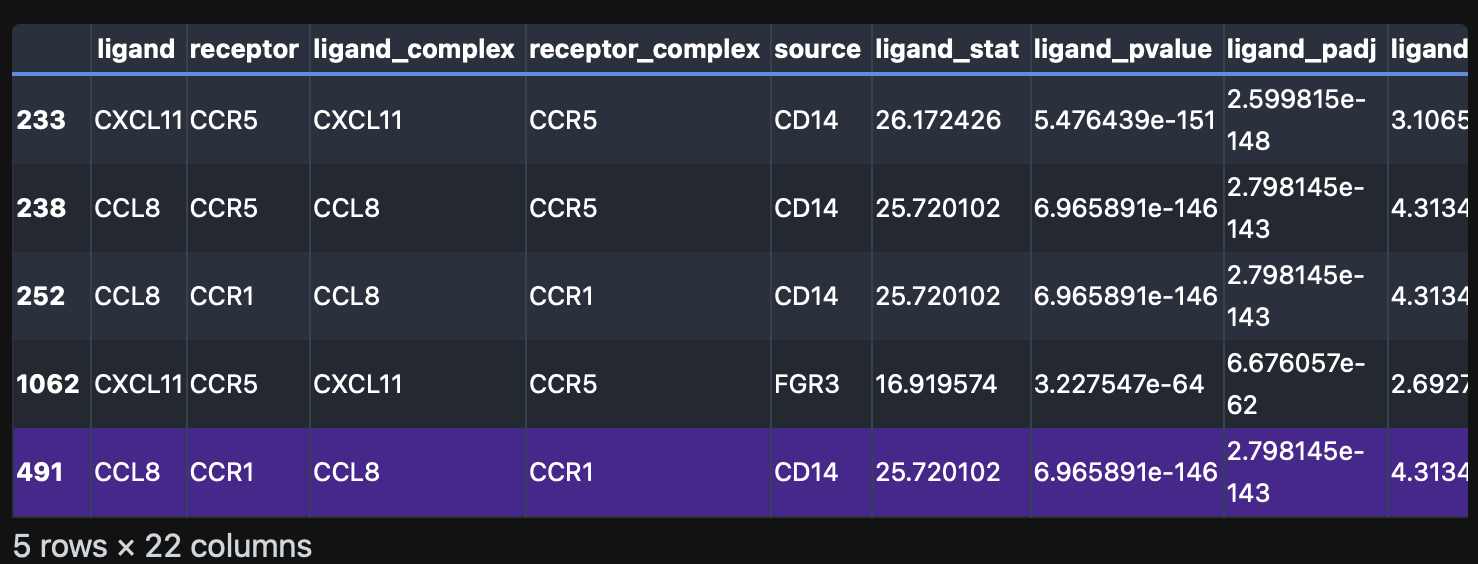
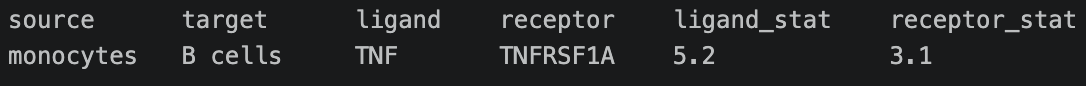

### DEA to ligand-receptor interactions: logic

#### 1. Check that the cell type column exists

Python:

```python
adata.obs["lineage"]
dea_df["lineage"]
```

R equivalent:

```r
seurat_obj$lineage
dea_table$lineage
```

The function needs the same cell type column in both objects, because it must know which DE result belongs to which cell type.

---

#### 2. Get ligand-receptor resource

Python:

```python
resource = _handle_resource(...)
```

This loads a table of known ligand-receptor pairs, for example:

```text
ligand    receptor
TNF       TNFRSF1A
IL1B      IL1R1
CXCL8     CXCR1
```

This is the biological prior: the function only searches among known LR pairs, not every gene-gene combination.

---

#### 3. Calculate expression per cell type

Python:

```python
adata = adata[adata.obs[condition_key] == "stim"].copy()

for label in labels:
    temp = adata[adata.obs[I.label] == label, :]
    props = _get_props(temp.X)
    means = temp.X.mean(axis=0)
```

Meaning:

```text
props = proportion of cells expressing each gene
means = average expression of each gene
```

They first subset to the condition of interest:

```python
adata = adata[adata.obs[condition_key] == "stim"].copy()
```

So expression values are calculated only in `stim`.

In our case, this corresponds to calculating expression only in:

```text
PLA
```

---

#### 4. Join expression information with DE results

For each cell type, the function combines:

```text
gene expression / proportion
+
DESeq2 statistics
```

Example output for one cell type:

```text
gene      lineage      expr    props    stat    pvalue    padj
TNF       monocytes    1.20    0.35     5.2     ...       0.001
IL1B      monocytes    0.95    0.28     4.8     ...       0.003
```

This is stored in `dedict`.

Conceptually:

```python
dedict["B cells"] = table of gene stats in B cells
dedict["monocytes"] = table of gene stats in monocytes
```

---

#### 5. Make all source-target cell type pairs

Python:

```python
pairs = pd.DataFrame(list(product(labels, labels)))
```

This creates every possible communication direction.

Example:

```text
source      target
B cells     B cells
B cells     T cells
B cells     monocytes
T cells     B cells
T cells     T cells
T cells     monocytes
monocytes   B cells
monocytes   T cells
monocytes   monocytes
```

So the function considers all possible directed cell-type pairs.

---

#### 6. For every source-target pair, attach ligand and receptor stats

Python:

```python
_join_stats(source, target, dedict, resource)
```

For one source-target pair:

```text
source = monocytes
target = B cells
```

the function takes every known ligand-receptor pair:

```text
ligand    receptor
TNF       TNFRSF1A
IL1B      IL1R1
```

Then it asks:

```text
does the ligand gene name match a gene in the source-cell DE table?
does the receptor gene name match a gene in the target-cell DE table?
```

Example known LR pair:

```text
ligand   = TNF
receptor = TNFRSF1A
```

Example source-target pair:

```text
source = monocytes
target = B cells
```

Your DE table contains:

```text
lineage      gene       stat    padj
monocytes    TNF        5.2     0.001
B cells      TNFRSF1A   3.1     0.020
```

Then the code can match:

```text
TNF + monocytes       -> found
TNFRSF1A + B cells    -> found
```

So it creates:

```text
source      target    ligand    receptor    ligand_stat    receptor_stat
monocytes   B cells   TNF       TNFRSF1A    5.2            3.1
```

This is done for:

```text
every source-target cell type pair × every known ligand-receptor pair
```

So it is a structured brute-force search over known LR pairs.

---

#### 7. Filter weakly expressed LR pairs

Python:

```python
filter_reassemble_complexes(..., expr_prop = expr_prop)
```

This removes interactions where the ligand or receptor is not expressed in enough cells.

For example, with:

```python
expr_prop = 0.1
```

the function keeps interactions only if:

```text
ligand is expressed in at least 10% of source cells
receptor is expressed in at least 10% of target cells
```

---

#### 8. Calculate interaction-level statistics

Python:

```python
for key in stat_names:
    lr_res[f"interaction_{key}"] = mean(ligand_key, receptor_key)
```

For example:

```text
interaction_stat = mean(ligand_stat, receptor_stat)
```

If:

```text
ligand_stat   = 5.2
receptor_stat = 3.1
```

then:

```text
interaction_stat = 4.15
```

This gives one score for the whole ligand-receptor interaction.

---

##### Simplified mental model

```text
1. take DE results per cell type
2. take known ligand-receptor pairs
3. create all source-target cell type pairs
4. for each source-target pair, check all known LR pairs
5. attach ligand DE stats from source
6. attach receptor DE stats from target
7. remove weakly expressed pairs
8. calculate one interaction score
```

In short:

```text
DE genes per cell type
+
known ligand-receptor database
+
all source-target cell type combinations
=
condition-relevant ligand-receptor interaction table
```

Adaptation in R:
- we already have dea_table with lineage, gene. stat, pvalue, padj, log2FoldChange
- we need a ligand-receptor resource


In [39]:
# 1. clean DE table (keep only genes that deseq actually tested)
dea_table_clean <- dea_table %>%
  select(lineage, gene, log2FoldChange, stat, pvalue, padj) %>%
  filter(!is.na(stat))

In [53]:
# 2. get known ligand-receptor pairs (consensus)
lr_resource_raw <- liana::select_resource("Consensus")

lr_resource <- lr_resource_raw$Consensus %>%
  dplyr::select(
    ligand = source_genesymbol,
    receptor = target_genesymbol
  ) %>%
  dplyr::distinct()

head(lr_resource)

ligand,receptor
<chr>,<chr>
LGALS9,PTPRC
LGALS9,MET
LGALS9,CD44
LGALS9,LRP1
LGALS9,CD47
LGALS9,PTPRK


In [55]:
# 3. make all source-target lineage pairs
lineages <- unique(dea_table_clean$lineage)

cell_pairs <- expand.grid(
  source = lineages,
  target = lineages,
  stringsAsFactors = FALSE
)

head(cell_pairs)

,source,target
,<chr>,<chr>
1,B cells,B cells
2,CD4 T cells,B cells
3,CD8 T cells,B cells
4,DCs,B cells
5,Monocytes,B cells
6,NK cells,B cells


In [56]:
# 4. prepare ligand DE stats
ligand_stats <- dea_table_clean %>%
  select(
    source = lineage,
    ligand = gene,
    ligand_log2FC = log2FoldChange,
    ligand_stat = stat,
    ligand_pvalue = pvalue,
    ligand_padj = padj
  )

# 5. prepare receptor DE stats
receptor_stats <- dea_table_clean %>%
  select(
    target = lineage,
    receptor = gene,
    receptor_log2FC = log2FoldChange,
    receptor_stat = stat,
    receptor_pvalue = pvalue,
    receptor_padj = padj
  )

head(ligand_stats)
head(receptor_stats)

,source,ligand,ligand_log2FC,ligand_stat,ligand_pvalue,ligand_padj
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
TNFRSF4...1,B cells,TNFRSF4,1.9681945,3.7349383,1.877612e-04,6.231043e-04
TNFRSF18...2,B cells,TNFRSF18,0.4149190,0.9259483,3.544729e-01,4.145809e-01
ATAD3B...3,B cells,ATAD3B,0.2590089,1.0344129,3.009432e-01,3.584588e-01
THAP3...4,B cells,THAP3,-0.4154261,-1.7511247,7.992443e-02,1.282116e-01
ENSG00000260179...5,B cells,ENSG00000260179,4.8303051,1.6539750,9.813259e-02,1.370573e-01
ENSG00000228037...6,B cells,ENSG00000228037,2.6259224,6.3109100,2.773995e-10,3.339475e-09


,target,receptor,receptor_log2FC,receptor_stat,receptor_pvalue,receptor_padj
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
TNFRSF4...1,B cells,TNFRSF4,1.9681945,3.7349383,1.877612e-04,6.231043e-04
TNFRSF18...2,B cells,TNFRSF18,0.4149190,0.9259483,3.544729e-01,4.145809e-01
ATAD3B...3,B cells,ATAD3B,0.2590089,1.0344129,3.009432e-01,3.584588e-01
THAP3...4,B cells,THAP3,-0.4154261,-1.7511247,7.992443e-02,1.282116e-01
ENSG00000260179...5,B cells,ENSG00000260179,4.8303051,1.6539750,9.813259e-02,1.370573e-01
ENSG00000228037...6,B cells,ENSG00000228037,2.6259224,6.3109100,2.773995e-10,3.339475e-09


In [ ]:
# 6. combine source-target pairs with ligand-receptor resource
# contains all possible combinations now
lr_res <- cell_pairs %>%
  crossing(lr_resource)

head(lr_res)

source,target,ligand,receptor
<chr>,<chr>,<chr>,<chr>
B cells,B cells,A2M,LRP1
B cells,B cells,AANAT,MTNR1A
B cells,B cells,AANAT,MTNR1B
B cells,B cells,ACE,AGTR2
B cells,B cells,ACE,BDKRB2
B cells,B cells,ACTR2,ADRB2


Attention: This table DOES NOT MEAN that B cells really express A2M, B cells really express LRP1. It only means A2M -> LRP1 is a known ligand-receptor pair and we are testing whether this pair is supported for B cells -> B cells. Its a broad candidate table.

In [60]:
# 7. join ligand stats from the source lineage
# this 
lr_res <- lr_res %>%
  left_join(ligand_stats, by = c("source", "ligand"))

# 8. join receptor stats from the target lineage
lr_res <- lr_res %>%
  left_join(receptor_stats, by = c("target", "receptor"))

In [59]:
head(dea_table_clean)

,lineage,gene,log2FoldChange,stat,pvalue,padj
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
TNFRSF4...1,B cells,TNFRSF4,1.9681945,3.7349383,1.877612e-04,6.231043e-04
TNFRSF18...2,B cells,TNFRSF18,0.4149190,0.9259483,3.544729e-01,4.145809e-01
ATAD3B...3,B cells,ATAD3B,0.2590089,1.0344129,3.009432e-01,3.584588e-01
THAP3...4,B cells,THAP3,-0.4154261,-1.7511247,7.992443e-02,1.282116e-01
ENSG00000260179...5,B cells,ENSG00000260179,4.8303051,1.6539750,9.813259e-02,1.370573e-01
ENSG00000228037...6,B cells,ENSG00000228037,2.6259224,6.3109100,2.773995e-10,3.339475e-09


Most confusing part:

- Each row in `lr_res` starts as one possible ligand-receptor interaction for one source-target cell type pair.

```text
source    target    ligand    receptor
B cells   B cells   A2M       LRP1
```

- This row is conceptually split into two lookup questions:

```text
source-ligand lookup:
B cells + A2M

target-receptor lookup:
B cells + LRP1
```

- Then we try to find these exact combinations in the DE table.

```text
lineage = B cells, gene = A2M
lineage = B cells, gene = LRP1
```

- To make the joins easier, the DE table is copied into two versions:

```text
ligand_stats:
lineage -> source
gene    -> ligand

receptor_stats:
lineage -> target
gene    -> receptor
```

- First, we create the large candidate table:

```text
all source-target pairs × all known ligand-receptor pairs
```

- Example:

```text
source    target    ligand    receptor
B cells   B cells   A2M       LRP1
B cells   B cells   AANAT     MTNR1A
B cells   B cells   ACE       AGTR2
```

- Then we left join ligand stats.

- This asks:

```text
does source + ligand exist in ligand_stats?
```

- Example lookup:

```text
B cells + A2M
B cells + AANAT
B cells + ACE
```

- If the pair is found, ligand DE statistics are added.

- If the pair is not found, the row is kept, but ligand statistics become `NA`.

```text
source    target    ligand    receptor    ligand_stat
B cells   B cells   A2M       LRP1        2.4
B cells   B cells   AANAT     MTNR1A      NA
B cells   B cells   ACE       AGTR2       1.7
```

- Then we left join receptor stats.

- This asks:

```text
does target + receptor exist in receptor_stats?
```

- Example lookup:

```text
B cells + LRP1
B cells + MTNR1A
B cells + AGTR2
```

- If the pair is found, receptor DE statistics are added.

- If the pair is not found, the row is kept, but receptor statistics become `NA`.

```text
source    target    ligand    receptor    ligand_stat    receptor_stat
B cells   B cells   A2M       LRP1        2.4            3.1
B cells   B cells   AANAT     MTNR1A      NA             0.8
B cells   B cells   ACE       AGTR2       1.7            NA
```

- Important: the second left join is not only done for rows where the ligand matched.

- Because it is a left join, all original `lr_res` rows stay in the table.

- So the ligand lookup and receptor lookup are independent.

```text
source + ligand    -> ligand statistics
target + receptor  -> receptor statistics
```

- Only after both joins do we usually filter.

```r
filter(!is.na(ligand_stat), !is.na(receptor_stat))
```

- This keeps only rows where both lookups succeeded.

- So this row:

```text
source    target    ligand    receptor
B cells   B cells   A2M       LRP1
```

means:

```text
Is A2M found in the DE table for B cells?
Is LRP1 found in the DE table for B cells?
```

- If both are found, we get:

```text
source    target    ligand    receptor    ligand_stat    receptor_stat
B cells   B cells   A2M       LRP1        2.4            3.1
```

- Then we can calculate one interaction-level score.

```text
interaction_stat = mean(ligand_stat, receptor_stat)
```

- Example:

```text
ligand_stat   = 2.4
receptor_stat = 3.1

interaction_stat = 2.75
```

- Final interpretation:

```text
B cells -> B cells | A2M -> LRP1
```

means:

```text
A2M is treated as the ligand from B cells.
LRP1 is treated as the receptor on B cells.

The interaction is kept/ranked if both genes have usable DE statistics in their corresponding cell type.
```

In [95]:
# 9. keep only pairs where both ligand and receptor have DE stats
# keep only interactions where ligand and receptor were both tested by DESeq2

# 10. make interaction scores
  # try stouffers method to combine 2 wald statistics

lr_res <- lr_res %>%
  #filter(!is.na(ligand_stat), !is.na(receptor_stat)) %>%

  mutate(
    # Stouffer's method using signed Wald statistics
    stouffer_interaction_z = (ligand_stat + receptor_stat) / sqrt(2),
    stouffer_interaction_pvalue = 2 * pnorm(-abs(stouffer_interaction_z)),
    stouffer_interaction_padj = p.adjust(stouffer_interaction_pvalue, method = "BH"),
    stouffer_interaction = paste(ligand, receptor, sep = "^"),

    # simple heuristic scores
    interaction_mean = (ligand_stat + receptor_stat) / 2,
    interaction_abs_mean = (abs(ligand_stat) + abs(receptor_stat)) / 2,

    # conservative gene-level padj summary
    interaction_max_padj = pmax(ligand_padj, receptor_padj),

    # readable LR name
    interaction = paste(ligand, receptor, sep = " → "),
    
    # readable lineage pair name
    lineage_pair = paste(source, target, sep = " → "),
  ) %>%
  arrange(stouffer_interaction_padj)

Stouffer's method does p-values -> z-scores -> combined z -> combined p-value. It assumes that the \(p\)-values to be combined are independent. If this is not the case, the method can either be conservative (not reject often enough) or liberal (reject too often), depending on the dependence structure among the tests. Cell-cell interaction might not be really independent.

Positivie interaction_mean means ligand & receptor tend to be higher in PLA, negative means ligand & receptor tend to be higher in platelet-free. 

- stouffer interaction_z > 0  = combined evidence tends toward higher in PLA
- stouffer interaction_z < 0  = combined evidence tends toward higher in platelet_free
- small stouffer interaction_padj = strong combined ligand+receptor DE evidence

Attention: The means, combined pvals are not actual statistics, rather directional heuristics. 
- large positive = ligand and receptor both tend to be higher in PLA
- large negative = ligand and receptor both tend to be higher in platelet_free
- near zero = weak or discordant evidence

In [96]:
# 11. sort strongest interactions first
lr_res <- lr_res %>%
  arrange(desc(interaction_abs_mean))

In [97]:
lr_res

source,target,ligand,receptor,ligand_log2FC,ligand_stat,ligand_pvalue,ligand_padj,receptor_log2FC,receptor_stat,⋯,receptor_padj,stouffer_interaction_z,stouffer_interaction_pvalue,stouffer_interaction_padj,stouffer_interaction,interaction_mean,interaction_abs_mean,interaction_max_padj,interaction,lineage_pair
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
B cells,B cells,ANXA1,FPR1,4.534691,20.98670,8.676148e-98,1.135870e-94,5.0604997,17.30486,⋯,8.878306e-65,27.076224,1.876578e-161,1.371685e-156,ANXA1^FPR1,19.145781,19.14578,8.878306e-65,ANXA1 → FPR1,B cells → B cells
B cells,B cells,ANXA1,DYSF,4.534691,20.98670,8.676148e-98,1.135870e-94,5.6822263,16.82281,⋯,2.851858e-61,26.735360,1.827498e-157,6.679049e-153,ANXA1^DYSF,18.904754,18.90475,2.851858e-61,ANXA1 → DYSF,B cells → B cells
B cells,B cells,S100A9,CD36,5.862892,19.01679,1.238255e-80,5.187546e-78,5.5049860,18.71772,⋯,1.144187e-75,26.682329,7.548360e-157,1.839158e-152,S100A9^CD36,18.867256,18.86726,1.144187e-75,S100A9 → CD36,B cells → B cells
B cells,B cells,PSAP,LRP1,2.059670,16.84711,1.101774e-63,1.923238e-61,5.4334370,20.50793,⋯,2.253708e-90,26.414001,9.461933e-154,1.729050e-149,PSAP^LRP1,18.677519,18.67752,1.923238e-61,PSAP → LRP1,B cells → B cells
B cells,B cells,CD14,TLR4,5.575458,20.30961,1.057363e-91,1.054694e-88,4.3122433,16.50861,⋯,4.972652e-59,26.034417,2.019917e-149,2.952917e-145,CD14^TLR4,18.409113,18.40911,4.972652e-59,CD14 → TLR4,B cells → B cells
B cells,B cells,PF4,LRP1,6.167448,15.74708,7.192400e-56,9.535392e-54,5.4334370,20.50793,⋯,2.253708e-90,25.636167,6.031516e-145,7.347894e-141,PF4^LRP1,18.127508,18.12751,9.535392e-54,PF4 → LRP1,B cells → B cells
B cells,B cells,S100A8,CD36,5.819785,17.46726,2.544131e-68,5.609675e-66,5.5049860,18.71772,⋯,1.144187e-75,25.586644,2.148345e-144,2.243332e-140,S100A8^CD36,18.092489,18.09249,5.609675e-66,S100A8 → CD36,B cells → B cells
B cells,B cells,AGTRAP,RACK1,2.837175,22.02832,1.541823e-107,4.037071e-104,-0.5192611,-14.06940,⋯,4.946760e-43,5.627809,1.825126e-08,1.472653e-07,AGTRAP^RACK1,3.979462,18.04886,4.946760e-43,AGTRAP → RACK1,B cells → B cells
B cells,B cells,VCAN,TLR2,5.359177,17.72404,2.735319e-70,6.366304e-68,4.4209941,18.01190,⋯,4.219921e-70,25.269128,6.980660e-141,6.378141e-137,VCAN^TLR2,17.867972,17.86797,6.366304e-68,VCAN → TLR2,B cells → B cells


# Plots

In [98]:
lr_plot <- lr_res %>%
  mutate(
    lineage_pair = paste(source, target, sep = " → "),
    interaction = paste(ligand, receptor, sep = " → "),

    direction = case_when(
      ligand_stat > 0 & receptor_stat > 0 ~ "PLA-up",
      ligand_stat < 0 & receptor_stat < 0 ~ "platelet-free-up",
      TRUE ~ "discordant"
    ),

    mean_signed_score = interaction_mean,
    mean_abs_score = interaction_abs_mean,

    stouffer_signed_score = stouffer_interaction_z,
    stouffer_abs_score = abs(stouffer_interaction_z)
  )

## 1. Global distribution of interaction categories

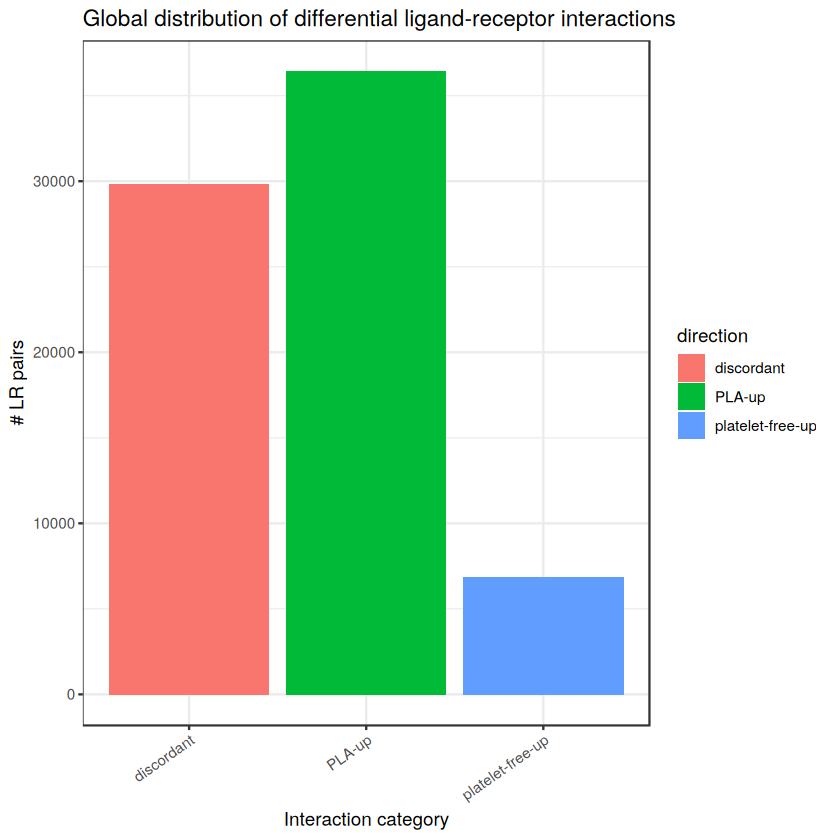

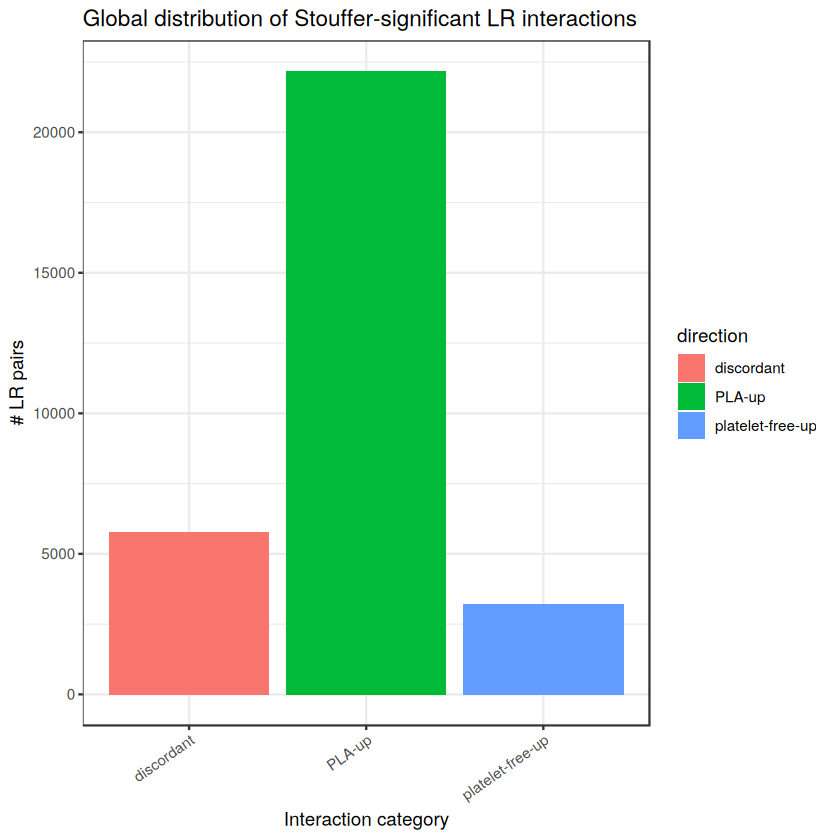

In [99]:
ggplot(lr_plot, aes(x = direction, fill = direction)) +
  geom_bar() +
  theme_bw() +
  labs(
    title = "Global distribution of differential ligand-receptor interactions",
    x = "Interaction category",
    y = "# LR pairs"
  ) +
  theme(axis.text.x = element_text(angle = 35, hjust = 1))

lr_plot_stouffer_sig <- lr_plot %>%
  filter(stouffer_interaction_padj < 0.05)

ggplot(lr_plot_stouffer_sig, aes(x = direction, fill = direction)) +
  geom_bar() +
  theme_bw() +
  labs(
    title = "Global distribution of Stouffer-significant LR interactions",
    x = "Interaction category",
    y = "# LR pairs"
  ) +
  theme(axis.text.x = element_text(angle = 35, hjust = 1))

## 2. Direction of LR interactions by source-target lineage pair

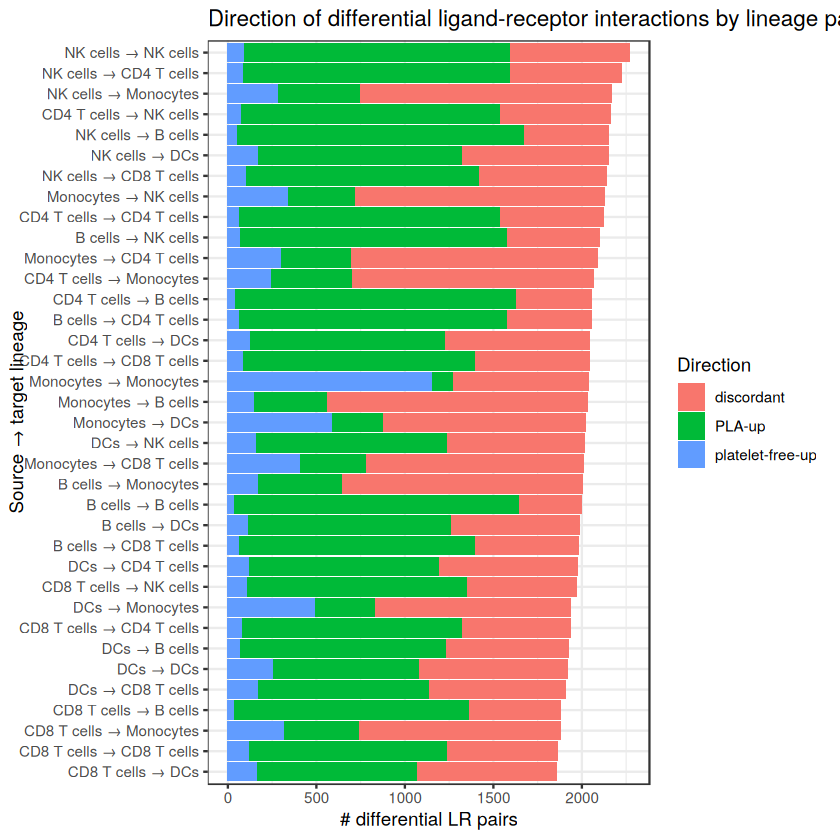

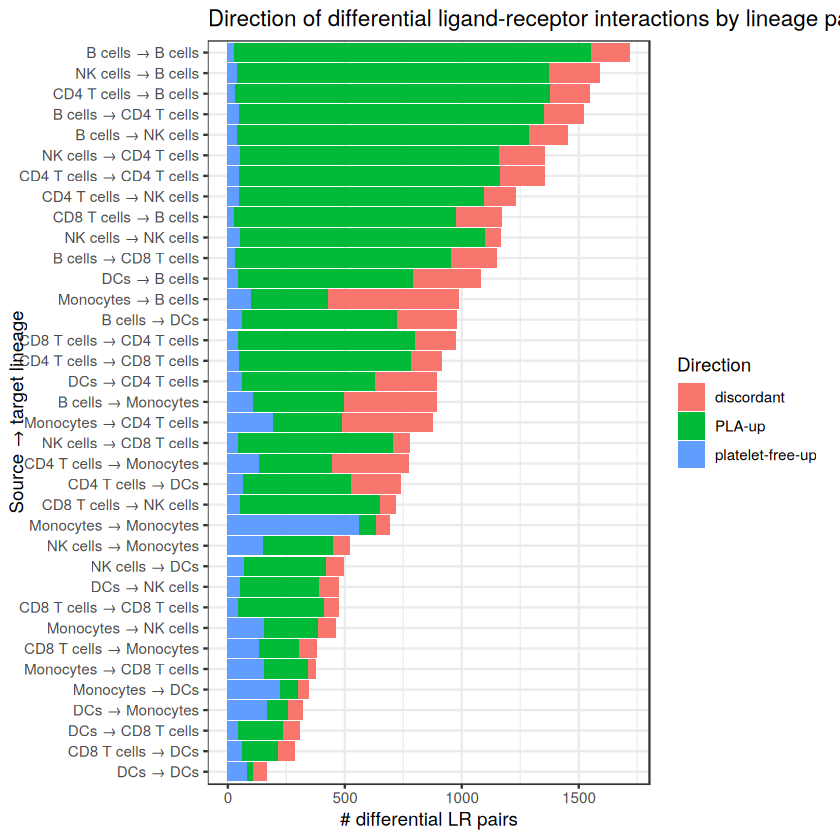

In [100]:
pair_counts <- lr_plot %>%
  dplyr::count(lineage_pair, direction) %>%
  dplyr::group_by(lineage_pair) %>%
  dplyr::mutate(total = sum(n)) %>%
  dplyr::ungroup() %>%
  dplyr::arrange(desc(total)) %>%
  dplyr::mutate(lineage_pair = fct_reorder(lineage_pair, total))

ggplot(pair_counts, aes(x = n, y = lineage_pair, fill = direction)) +
  geom_col() +
  theme_bw() +
  labs(
    title = "Direction of differential ligand-receptor interactions by lineage pair",
    x = "# differential LR pairs",
    y = "Source → target lineage",
    fill = "Direction"
  )

lr_plot_stouffer_sig <- lr_plot %>%
  filter(stouffer_interaction_padj < 0.05)

pair_counts_stouffer <- lr_plot_stouffer_sig %>%
dplyr::count(lineage_pair, direction) %>%
dplyr::group_by(lineage_pair) %>%
dplyr::mutate(total = sum(n)) %>%
dplyr::ungroup() %>%
dplyr::arrange(desc(total)) %>%
dplyr::mutate(lineage_pair = fct_reorder(lineage_pair, total))

ggplot(pair_counts_stouffer, aes(x = n, y = lineage_pair, fill = direction)) +
geom_col() +
theme_bw() +
labs(
  title = "Direction of differential ligand-receptor interactions by lineage pair (Stouffer stats)",
  x = "# differential LR pairs",
  y = "Source → target lineage",
  fill = "Direction"
)

## 3. Net direction heatmap

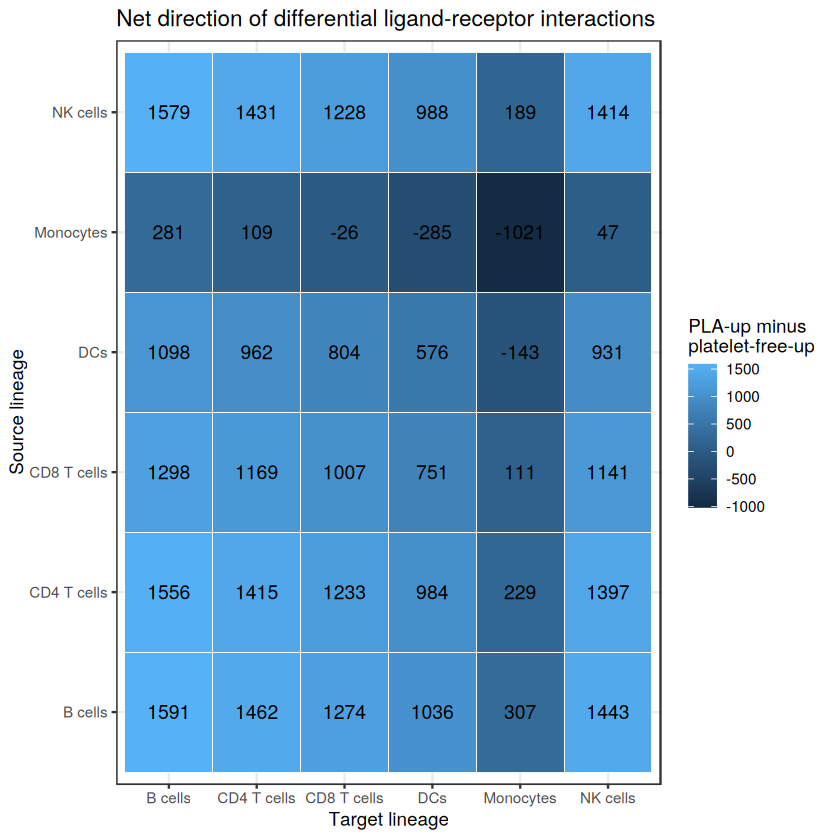

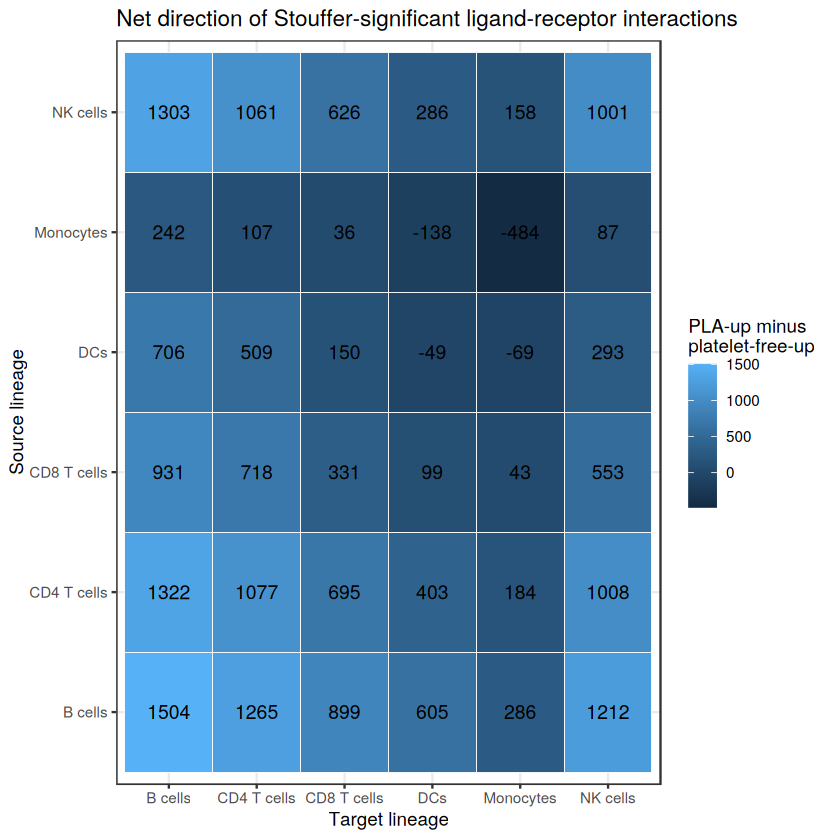

In [101]:
net_direction <- lr_plot %>%
  dplyr::filter(direction != "discordant") %>%
  dplyr::count(source, target, direction) %>%
  pivot_wider(
    names_from = direction,
    values_from = n,
    values_fill = 0
  ) %>%
  dplyr::mutate(
    net = `PLA-up` - `platelet-free-up`
  )

ggplot(net_direction, aes(x = target, y = source, fill = net)) +
  geom_tile(color = "white") +
  geom_text(aes(label = net), size = 4) +
  theme_bw() +
  labs(
    title = "Net direction of differential ligand-receptor interactions",
    x = "Target lineage",
    y = "Source lineage",
    fill = "PLA-up minus\nplatelet-free-up"
  )

net_direction_stouffer <- lr_plot_stouffer_sig %>%
  dplyr::filter(direction != "discordant") %>%
  dplyr::count(source, target, direction) %>%
  pivot_wider(
    names_from = direction,
    values_from = n,
    values_fill = 0
  ) %>%
  mutate(
    net = `PLA-up` - `platelet-free-up`
  )

ggplot(net_direction_stouffer, aes(x = target, y = source, fill = net)) +
  geom_tile(color = "white") +
  geom_text(aes(label = net), size = 4) +
  theme_bw() +
  labs(
    title = "Net direction of Stouffer-significant ligand-receptor interactions",
    x = "Target lineage",
    y = "Source lineage",
    fill = "PLA-up minus\nplatelet-free-up"
  )

## 4. Most recurrent LR pairs

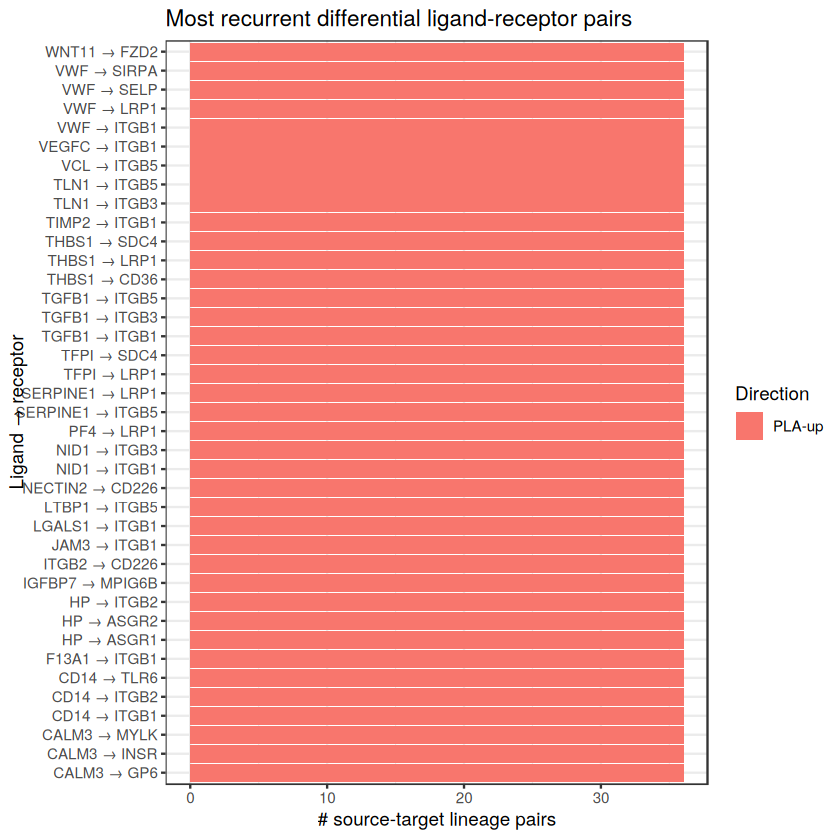

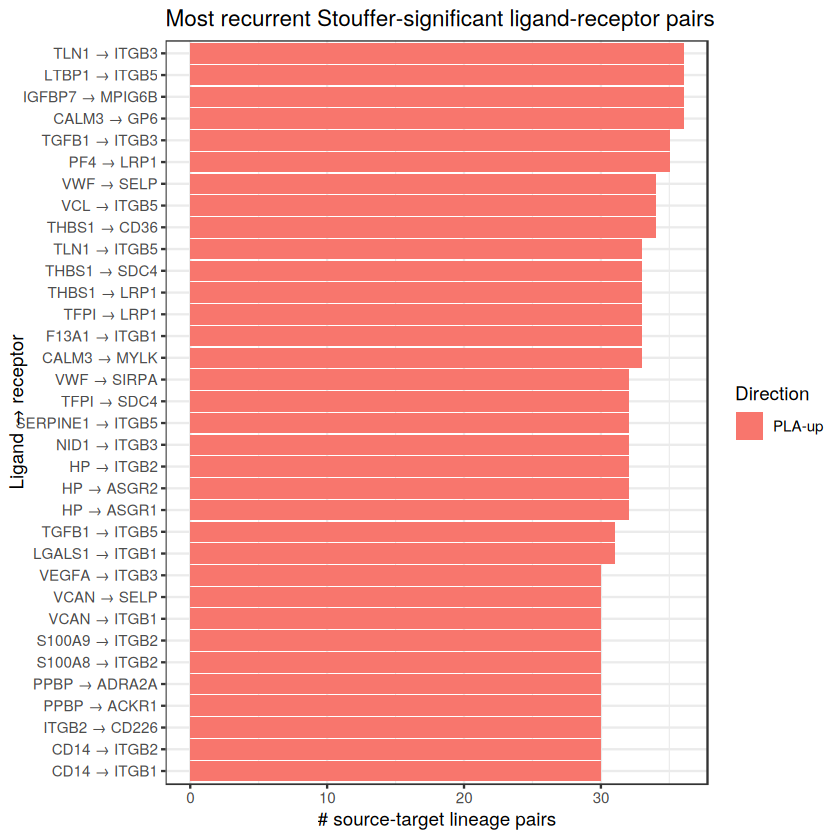

In [102]:
top_recurrent <- lr_plot %>%
  dplyr::filter(direction != "discordant") %>%
  dplyr::count(interaction, direction, name = "n_lineage_pairs") %>%
  dplyr::group_by(interaction) %>%
  dplyr::mutate(total = sum(n_lineage_pairs)) %>%
  dplyr::ungroup() %>%
  dplyr::slice_max(total, n = 25) %>%
  dplyr::mutate(interaction = fct_reorder(interaction, total))

ggplot(top_recurrent, aes(x = n_lineage_pairs, y = interaction, fill = direction)) +
  geom_col() +
  theme_bw() +
  labs(
    title = "Most recurrent differential ligand-receptor pairs",
    x = "# source-target lineage pairs",
    y = "Ligand → receptor",
    fill = "Direction"
  )

top_recurrent_stouffer <- lr_plot_stouffer_sig %>%
  dplyr::filter(direction != "discordant") %>%
  dplyr::count(interaction, direction, name = "n_lineage_pairs") %>%
  dplyr::group_by(interaction) %>%
  dplyr::mutate(total = sum(n_lineage_pairs)) %>%
  dplyr::ungroup() %>%
  dplyr::slice_max(total, n = 25) %>%
  dplyr::mutate(interaction = fct_reorder(interaction, total))

ggplot(top_recurrent_stouffer, aes(x = n_lineage_pairs, y = interaction, fill = direction)) +
  geom_col() +
  theme_bw() +
  labs(
    title = "Most recurrent Stouffer-significant ligand-receptor pairs",
    x = "# source-target lineage pairs",
    y = "Ligand → receptor",
    fill = "Direction"
  )

## 5. Top LR interactions per lineage pair

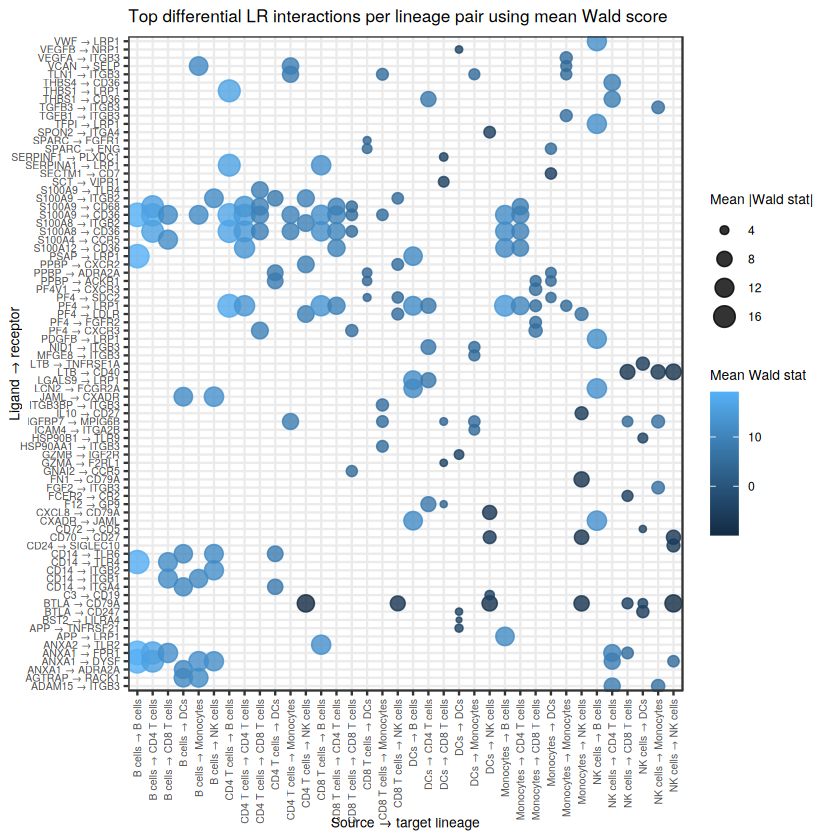

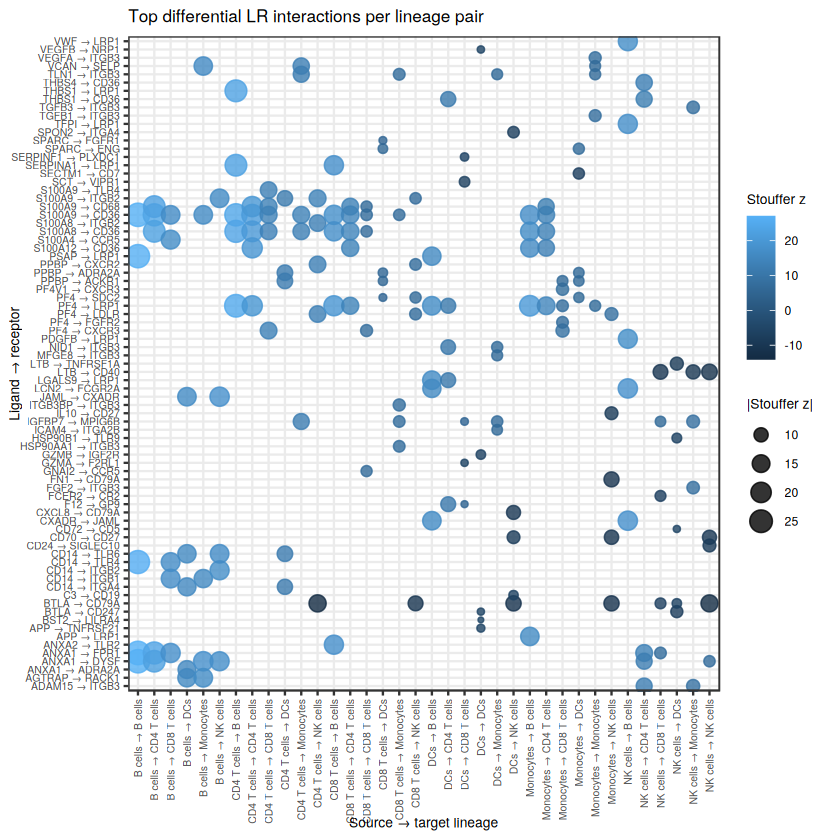

In [103]:
top_lr_per_pair_mean <- lr_plot %>%
  filter(direction != "discordant") %>%
  group_by(lineage_pair) %>%
  slice_max(mean_abs_score, n = 5, with_ties = FALSE) %>%
  ungroup()

ggplot(
  top_lr_per_pair_mean,
  aes(
    x = lineage_pair,
    y = interaction,
    size = mean_abs_score,
    color = mean_signed_score
  )
) +
  geom_point(alpha = 0.8) +
  theme_bw() +
  labs(
    title = "Top differential LR interactions per lineage pair using mean Wald score",
    x = "Source → target lineage",
    y = "Ligand → receptor",
    size = "Mean |Wald stat|",
    color = "Mean Wald stat"
  ) +
  theme(
  axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 6),
  axis.text.y = element_text(size = 6),
  axis.title.x = element_text(size = 8),
  axis.title.y = element_text(size = 8),
  plot.title = element_text(size = 10),
  legend.title = element_text(size = 8),
  legend.text = element_text(size = 7)
)

top_lr_per_pair_stouffer <- lr_plot_stouffer_sig %>%
  filter(direction != "discordant") %>%
  group_by(lineage_pair) %>%
  slice_max(stouffer_abs_score, n = 5, with_ties = FALSE) %>%
  ungroup()

ggplot(
  top_lr_per_pair_stouffer,
  aes(
    x = lineage_pair,
    y = interaction,
    size = stouffer_abs_score,
    color = stouffer_signed_score
  )
) +
  geom_point(alpha = 0.8) +
  theme_bw() +
  labs(
    title = "Top differential LR interactions per lineage pair",
    x = "Source → target lineage",
    y = "Ligand → receptor",
    size = "|Stouffer z|",
    color = "Stouffer z"
  ) +
  theme(
  axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 6),
  axis.text.y = element_text(size = 6),
  axis.title.x = element_text(size = 8),
  axis.title.y = element_text(size = 8),
  plot.title = element_text(size = 10),
  legend.title = element_text(size = 8),
  legend.text = element_text(size = 7)
)

6. Stauffer vs Mean

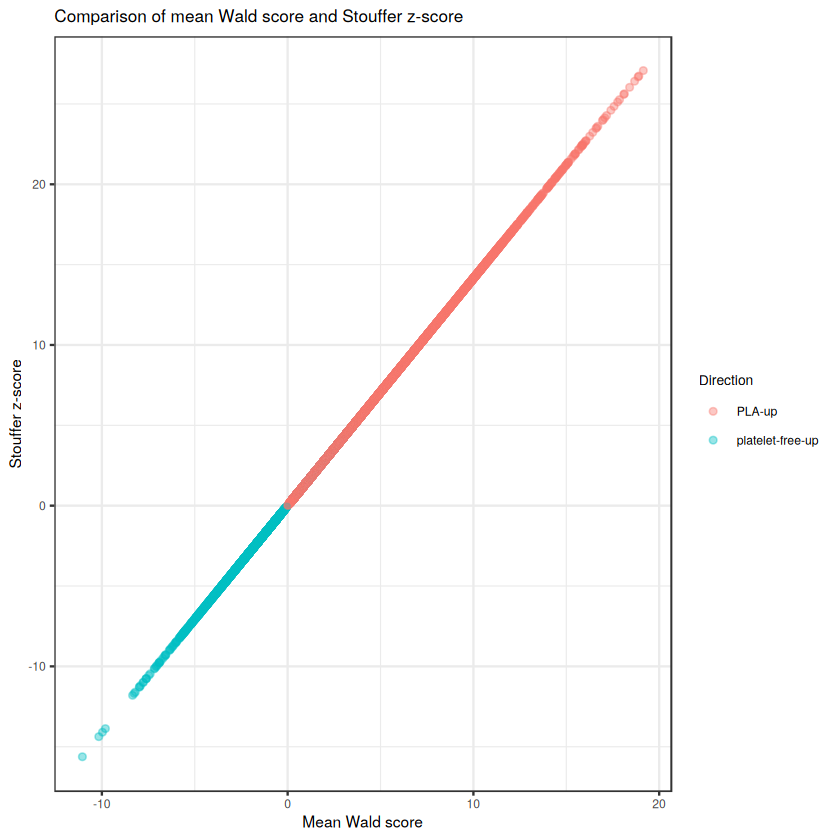

In [104]:
compare_scores <- lr_plot %>%
  filter(direction != "discordant") %>%
  mutate(
    interaction_label = paste(lineage_pair, interaction, sep = " | ")
  )

ggplot(
  compare_scores,
  aes(
    x = mean_signed_score,
    y = stouffer_signed_score,
    color = direction
  )
) +
  geom_point(alpha = 0.4, size = 1.5) +
  theme_bw() +
  labs(
    title = "Comparison of mean Wald score and Stouffer z-score",
    x = "Mean Wald score",
    y = "Stouffer z-score",
    color = "Direction"
  ) +
  theme(
    axis.text = element_text(size = 7),
    axis.title = element_text(size = 9),
    plot.title = element_text(size = 10),
    legend.title = element_text(size = 8),
    legend.text = element_text(size = 7)
  )

- interaction_mean = (ligand_stat + receptor_stat) / 2
- stouffer_interaction_z = (ligand_stat + receptor_stat) / sqrt(2)

- same numerator, only denominator changes
- ranking by signed mean Wald score and signed Stouffer z-score is almost identical

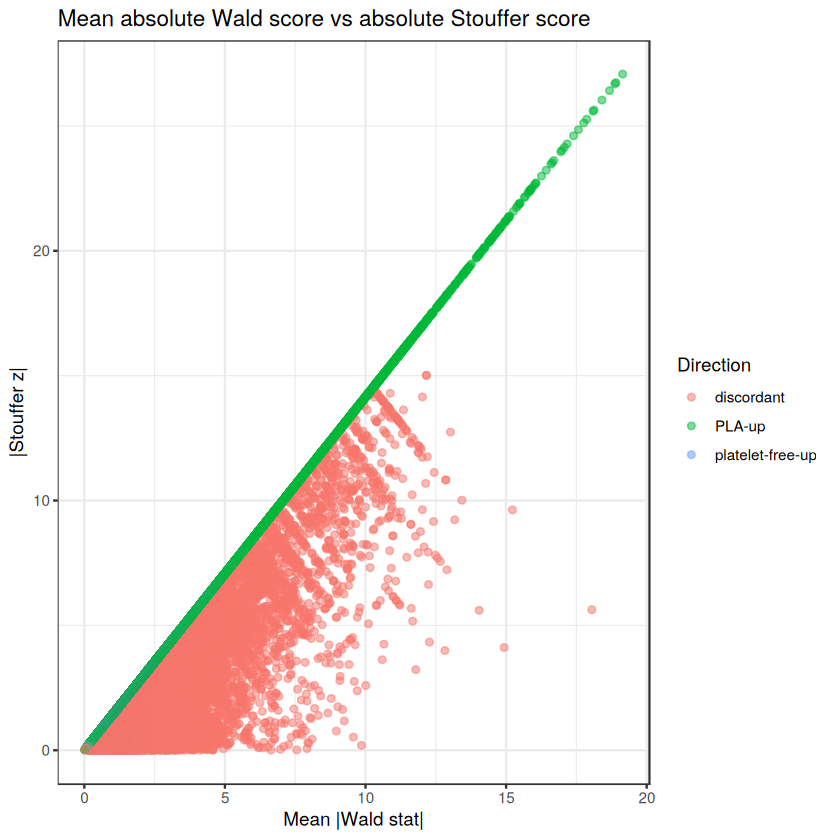

In [105]:
ggplot(
  lr_plot,
  aes(
    x = mean_abs_score,
    y = stouffer_abs_score,
    color = direction
  )
) +
  geom_point(alpha = 0.5, size = 1.5) +
  theme_bw() +
  labs(
    title = "Mean absolute Wald score vs absolute Stouffer score",
    x = "Mean |Wald stat|",
    y = "|Stouffer z|",
    color = "Direction"
  )

- green diagonal = ligand and receptor are both higher in PLA
- red cloud = ligand_stat > 0, receptor_stat < 0 or ligand_stat < 0, receptor_stat > 0
    - stouffer z lower because: mean_abs_score = (abs(8) + abs(-8)) / 2 = 8 vs. stouffer_abs_score = abs(8 + -8) / sqrt(2) = 0

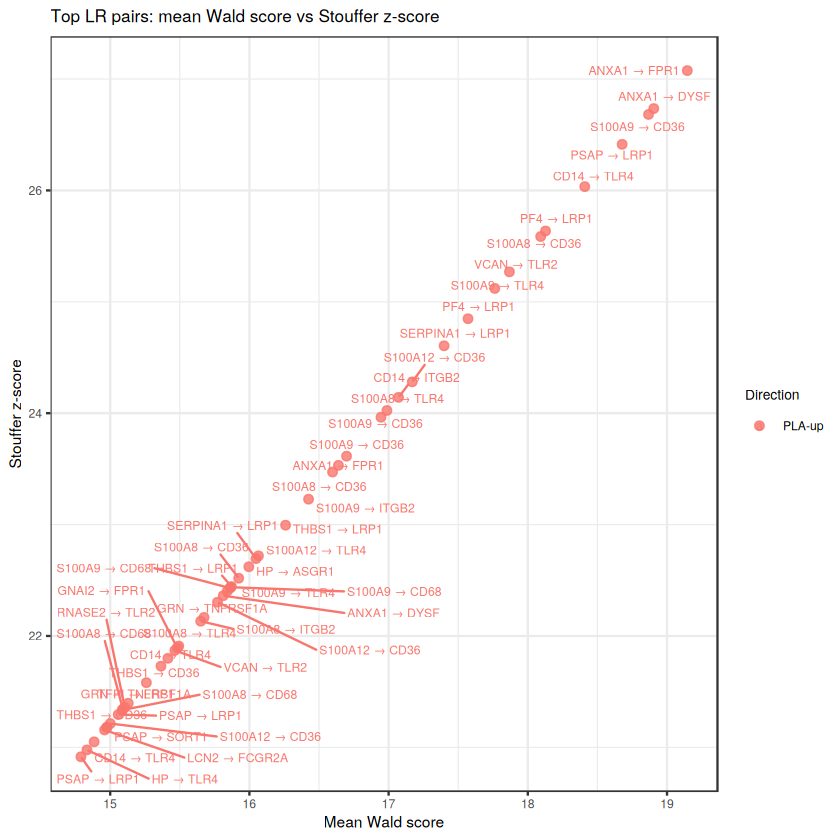

In [106]:
top_compare <- lr_plot %>%
  filter(direction != "discordant") %>%
  mutate(
    max_rank_score = pmax(abs(mean_signed_score), abs(stouffer_signed_score))
  ) %>%
  slice_max(max_rank_score, n = 50, with_ties = FALSE)

ggplot(
  top_compare,
  aes(
    x = mean_signed_score,
    y = stouffer_signed_score,
    color = direction,
    label = interaction
  )
) +
  geom_point(alpha = 0.8, size = 2) +
  ggrepel::geom_text_repel(size = 2.5, max.overlaps = 20) +
  theme_bw() +
  labs(
    title = "Top LR pairs: mean Wald score vs Stouffer z-score",
    x = "Mean Wald score",
    y = "Stouffer z-score",
    color = "Direction"
  ) +
  theme(
    axis.text = element_text(size = 7),
    axis.title = element_text(size = 9),
    plot.title = element_text(size = 10),
    legend.title = element_text(size = 8),
    legend.text = element_text(size = 7)
  )

Why so many PLA-up pairs?
- contrast: any positive DE signak becomes pla-up by default
- global activation state: pla may induce broad immunce acitvation, adhesion, chemokine, integrin, infammatory progrms. then many ligands/receptors become positive together
- some genes occur in many LR pairs. If such a ligand/receptor is PLA-up, it creates many PLA-up interactions, e.g. integrins, CD44, CD36, LRP1, TLRs, collagens, S100 genes, ANXA genes, THBS genes
- some gene PAIRS can occur in many source-target lineage pairs:
    - Monocytes → B cells     | THBS1 → CD36
    - Monocytes → CD4 T cells | THBS1 → CD36
    - B cells → CD4 T cells   | THBS1 → CD36
    - CD4 T cells → B cells   | THBS1 → CD36
-  missing platelet-free-only lineages/cell states: earlier we had some lineages with only platelet-free and no PLA, which were skipped in DESeq2, which can reduce possible platelet-free-up calls in some compartments
- we might be counting repeated LR pairs across many lineage pairs: THBS1 → CD36 appearing in 20 source-target pairs counts 20 times, which can make global plots look very PLA-heavy

For the last point some additional test:

In [116]:
lr_plot %>%
  filter(direction != "discordant") %>%
  dplyr::count(direction)

direction,n
<chr>,<int>
PLA-up,36418
platelet-free-up,6852


In [ ]:
# unqiue
lr_plot %>%
  filter(direction != "discordant") %>%
  distinct(interaction, direction) %>%
  dplyr::count(direction)

direction,n
<chr>,<int>
PLA-up,2625
platelet-free-up,1652


In [120]:
nrow(lr_plot)

lr_plot %>%
  distinct(interaction) %>%
  nrow()

[1] 73095

[1] 2754

PLA-up dominance is partly real at the unique LR-pair level, but it is strongly amplified by repeated occurrence across many lineage pairs.

In [ ]:
# most repeated lr pairs
lr_plot %>%
  filter(direction != "discordant") %>%
  group_by(interaction, direction) %>%
  summarise(
    n_lineage_pairs = n_distinct(lineage_pair),
    .groups = "drop"
  ) %>%
  arrange(desc(n_lineage_pairs)) %>%
  head(30)

interaction,direction,n_lineage_pairs
<chr>,<chr>,<int>
CALM3 → GP6,PLA-up,36
CALM3 → INSR,PLA-up,36
CALM3 → MYLK,PLA-up,36
CD14 → ITGB1,PLA-up,36
CD14 → ITGB2,PLA-up,36
CD14 → TLR6,PLA-up,36
F13A1 → ITGB1,PLA-up,36
HP → ASGR1,PLA-up,36
HP → ASGR2,PLA-up,36


interaction,n_lineage_pairs
<chr>,<int>
CALM3 → GP6,36
CALM3 → INSR,36
CALM3 → MYLK,36
CD14 → ITGB1,36
CD14 → ITGB2,36
CD14 → TLR6,36
F13A1 → ITGB1,36
HP → ASGR1,36
HP → ASGR2,36


Platelet-free UP:

In [114]:
platelet_free_pairs <- lr_plot %>%
  filter(
    ligand_stat < 0,
    receptor_stat < 0
  ) %>%
  arrange(stouffer_interaction_padj)

head(platelet_free_pairs)

platelet_free_pairs %>%
  dplyr::count(source, target, sort = TRUE)

platelet_free_pairs %>%
  dplyr::count(interaction, sort = TRUE) %>%
  head(30)

source,target,ligand,receptor,ligand_log2FC,ligand_stat,ligand_pvalue,ligand_padj,receptor_log2FC,receptor_stat,⋯,interaction_mean,interaction_abs_mean,interaction_max_padj,interaction,lineage_pair,direction,mean_signed_score,mean_abs_score,stouffer_signed_score,stouffer_abs_score
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
NK cells,B cells,LTB,CD40,-2.4743720,-12.021850,2.727940e-33,4.703651e-30,-1.469344,-10.076798,⋯,-11.049324,11.049324,2.348786e-22,LTB → CD40,NK cells → B cells,platelet-free-up,-11.049324,11.049324,-15.62610,15.62610
B cells,NK cells,BTLA,CD79A,-1.3292564,-6.643530,3.062572e-11,4.130824e-10,-5.404901,-13.685413,⋯,-10.164472,10.164472,4.130824e-10,BTLA → CD79A,B cells → NK cells,platelet-free-up,-10.164472,10.164472,-14.37473,14.37473
CD4 T cells,NK cells,BTLA,CD79A,-0.8042069,-6.251336,4.069572e-10,5.356498e-09,-5.404901,-13.685413,⋯,-9.968374,9.968374,5.356498e-09,BTLA → CD79A,CD4 T cells → NK cells,platelet-free-up,-9.968374,9.968374,-14.09741,14.09741
NK cells,NK cells,BTLA,CD79A,-2.4960594,-5.934209,2.952661e-09,5.091125e-07,-5.404901,-13.685413,⋯,-9.809811,9.809811,5.091125e-07,BTLA → CD79A,NK cells → NK cells,platelet-free-up,-9.809811,9.809811,-13.87317,13.87317
B cells,B cells,LTB,CD40,-1.3557539,-6.615137,3.712090e-11,4.952685e-10,-1.469344,-10.076798,⋯,-8.345967,8.345967,4.952685e-10,LTB → CD40,B cells → B cells,platelet-free-up,-8.345967,8.345967,-11.80298,11.80298
NK cells,NK cells,LTB,CD40,-2.4743720,-12.021850,2.727940e-33,4.703651e-30,-1.096966,-4.505683,⋯,-8.263767,8.263767,1.933489e-04,LTB → CD40,NK cells → NK cells,platelet-free-up,-8.263767,8.263767,-11.68673,11.68673


source,target,n
<chr>,<chr>,<int>
Monocytes,Monocytes,1148
Monocytes,DCs,583
DCs,Monocytes,488
Monocytes,CD8 T cells,404
Monocytes,NK cells,338
CD8 T cells,Monocytes,317
Monocytes,CD4 T cells,295
NK cells,Monocytes,279
DCs,DCs,254


interaction,n
<chr>,<int>
BTLA → CD247,30
BTLA → CD79A,30
BTLA → TNFRSF14,30
CCL28 → CCR10,30
LTA → TNFRSF14,30
MIF → TNFRSF14,30
EFNA4 → EPHA4,25
HLA-B → CD3D,25
IL16 → KCNA3,25
